In [1]:
import os
import gc
import numpy as np
import pandas as pd
import tifffile

directory = "/mlbio_scratch/anagupta/luna/data/train_test_split_1/slice_images"

dfs = []
tiffs = {}

files = os.listdir(directory)

for file in files:
    if file.endswith(".ome.tif"):
        filename = file.split('.')[0].removesuffix('_morphology_focus')
        tiff = tifffile.imread(os.path.join(directory, file), is_ome=False, level=0)
        tiffs[filename] = tiff
        print(f"Loaded {directory} with shape {tiff.shape}")

Loaded /mlbio_scratch/anagupta/luna/data/train_test_split_1/slice_images with shape (24864, 31348)
Loaded /mlbio_scratch/anagupta/luna/data/train_test_split_1/slice_images with shape (20739, 28492)
Loaded /mlbio_scratch/anagupta/luna/data/train_test_split_1/slice_images with shape (20741, 28491)
Loaded /mlbio_scratch/anagupta/luna/data/train_test_split_1/slice_images with shape (24863, 31342)
Loaded /mlbio_scratch/anagupta/luna/data/train_test_split_1/slice_images with shape (20727, 28494)
Loaded /mlbio_scratch/anagupta/luna/data/train_test_split_1/slice_images with shape (24869, 28482)


In [1]:
import pandas as pd
data = pd.read_csv('/mlbio_scratch/anagupta/xenium_preprocessed/10xgenomics_alzheimers_disease_mouse_data_shuffled.csv')
print("Loaded data: ", data.shape)
print(data.columns)

KeyboardInterrupt: 

In [4]:
print(data.columns.tolist())
# cell_section

['cell_id', 'coord_X', 'coord_Y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_class', 'cell_section', 'donor', '2010300C02Rik', 'Abca7', 'Acsbg1', 'Acta2', 'Acvrl1', 'Adamts2', 'Adamtsl1', 'Adgrl4', 'Aldh1a2', 'Aldh1l1', 'Angpt1', 'Ano1', 'Apod', 'Apoe', 'Aqp4', 'Arc', 'Arhgap12', 'Arhgap25', 'Arhgap6', 'Arhgef28', 'Aspg', 'B2m', 'Bcl11b', 'Bdnf', 'Bhlhe22', 'Bhlhe40', 'Btbd11', 'C1qa', 'C1qb', 'C1qc', 'C3', 'C4a', 'C4b', 'Cabp7', 'Cacna2d2', 'Calb1', 'Calb2', 'Car4', 'Carmn', 'Cbln1', 'Cbln4', 'Ccn2', 'Cd14', 'Cd24a', 'Cd300c2', 'Cd33', 'Cd44', 'Cd53', 'Cd63', 'Cd68', 'Cd69', 'Cd74', 'Cd93', 'Cdh13', 'Cdh20', 'Cdh4', 'Cdh6', 'Cdh9', 'Chat', 'Chodl', 'Chrm2', 'Cldn5', 'Clmn', 'Clu', 'Cnp', 'Cntn6', 'Cntnap4', 'Cntnap5b', 'Cobll1', 'Col19a1', 'Col1a1', 'Col6a1', 'Cort', 'Cplx3', 'Cpne4', 'Cpne6', 'Cpne8', 'Crh', 'Cryab', 'Csf1r', 'Cspg4', 'Cst3', 'Ctsa', 'Ctsb', 'Ctsd', 'Ctsh', '

In [ ]:
# plot some of the tiffs
import matplotlib.pyplot as plt
for i in range(2):
    plt.imshow(tiffs[list(tiffs.keys())[i]], cmap='gray')
    plt.show()
    break

In [ ]:
# print coord_X and coord_Y limits
print(data['coord_X'].min(), data['coord_X'].max(), data['coord_Y'].min(), data['coord_Y'].max())
print(len(data['cell_id'].unique()), len(data))

In [5]:
def window_slicing(tiff, data, window_size=8192, overlap=128):
    h, w = tiff.shape[:2]
    for i in range(0, h, window_size - overlap):
        for j in range(0, w, window_size - overlap):
            window = tiff[i:i+window_size, j:j+window_size]
            if window.shape[0] != window_size or window.shape[1] != window_size:
                window = np.pad(window, ((0, window_size - window.shape[0]), (0, window_size - window.shape[1])), mode='constant', constant_values=0)
            scale_factor = .2125 # um/px
            px_min = j * scale_factor
            px_max = (j + window_size) * scale_factor
            py_min = i * scale_factor
            py_max = (i + window_size) * scale_factor
            # print(px_min, px_max, py_min, py_max)
            window_data = data[
                (data['coord_X'] >= px_min ) &
                (data['coord_Y'] >= py_min ) &
                (data['coord_X'] < px_max) &
                (data['coord_Y'] < py_max)
            ]
            # window_data = data.filter(pl.col("coord_X").ge(px_min) & pl.col("coord_Y").ge(py_min) & pl.col("coord_X").lt(px_max) & pl.col("coord_Y").lt(py_max))
            yield window, window_data, px_min, py_min

In [25]:
sliced_tiffs = {}
sliced_data = []

donors = data['donor'].unique()

all_ids = set()
for donor in donors:
    donor_data = data[data['donor'] == donor]
    tiff = tiffs[donor]
    i = 1
    for window, window_data, offset_x, offset_y in window_slicing(tiff, donor_data):
        slice_name = donor + '__' + str(i)
        sliced_tiffs[slice_name] = window
        
        if not window_data.empty:
            target_ids = set(window_data['cell_id'].unique())
            mask = data['cell_id'].isin(target_ids)
            data.loc[mask, 'cell_section'] = slice_name
            data.loc[mask, 'coord_X'] -= offset_x
            data.loc[mask, 'coord_Y'] -= offset_y
        
        sliced_data.append(window_data)
        ids = set(window_data['cell_id'])
        overlap = all_ids & ids
        # if overlap:
        #     print(f"Overlap found in {donor} {i}")
        #     print(overlap)
        all_ids.update(ids)
        i += 1
    print(f"Sliced {i-1} windows from {tiff.shape}")

print(len(sliced_tiffs))
print(len(sliced_data))

sum = 0
for i in range(len(sliced_data)):
    sum = sum + sliced_data[i].shape[0]

print(sum)

Sliced 17 windows from (24869, 28482)
Sliced 17 windows from (24863, 31342)
Sliced 17 windows from (24864, 31348)
Sliced 13 windows from (20739, 28492)
Sliced 13 windows from (20727, 28494)
Sliced 13 windows from (20741, 28491)
84
84
360567


In [28]:
# print number of points in each slice data
for i in range(len(sliced_data)):
    print(f"Slice {i} has {sliced_data[i].shape[0]} points")


Slice 0 has 3556 points
Slice 1 has 4250 points
Slice 2 has 4312 points
Slice 3 has 3147 points
Slice 4 has 7013 points
Slice 5 has 7875 points
Slice 6 has 8197 points
Slice 7 has 2618 points
Slice 8 has 2260 points
Slice 9 has 8353 points
Slice 10 has 6964 points
Slice 11 has 1700 points
Slice 12 has 1 points
Slice 13 has 143 points
Slice 14 has 36 points
Slice 15 has 0 points
Slice 16 has 4316 points
Slice 17 has 3847 points
Slice 18 has 4215 points
Slice 19 has 2195 points
Slice 20 has 6231 points
Slice 21 has 6554 points
Slice 22 has 7902 points
Slice 23 has 4163 points
Slice 24 has 5032 points
Slice 25 has 8681 points
Slice 26 has 7436 points
Slice 27 has 627 points
Slice 28 has 55 points
Slice 29 has 434 points
Slice 30 has 130 points
Slice 31 has 16 points
Slice 32 has 5868 points
Slice 33 has 8307 points
Slice 34 has 6313 points
Slice 35 has 5021 points
Slice 36 has 4966 points
Slice 37 has 7620 points
Slice 38 has 8050 points
Slice 39 has 4505 points
Slice 40 has 509 points
Sl

: 

In [27]:
data_dir = '/mlbio_scratch/anagupta/xenium_preprocessed/sliced_data'
os.makedirs(data_dir, exist_ok=True)

# save the concatenated data as csv
data.to_csv(os.path.join(data_dir, 'data.csv'), index=False)

In [26]:
data['cell_section']

0           wildtype_5_7__6
1          wildtype_5_7__11
2          wildtype_13_4__6
3           wildtype_5_7__5
4           TgCRND8_17_9__3
                ...        
350292       TgCRND8_5_7__7
350293      wildtype_2_5__5
350294      wildtype_2_5__1
350295      TgCRND8_2_5__11
350296    wildtype_13_4__11
Name: cell_section, Length: 350297, dtype: object

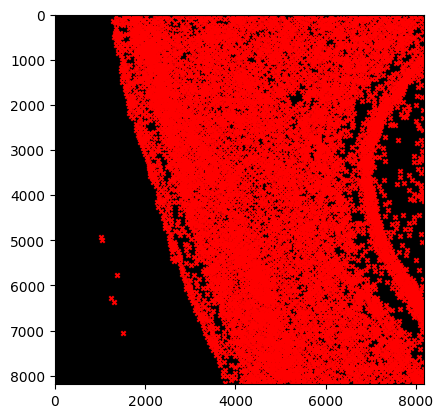

In [5]:
coord_x = sliced_data[4]['coord_X']
coord_y = sliced_data[4]['coord_Y']
scale_factor = .2125 # um/px
# construct a 8192x8192 numpy array with the coordinates
coord_array = np.zeros((8192, 8192))
px = coord_y/scale_factor
py = coord_x/scale_factor

# get the int pixels around px, py as size 10*10
px_int = np.floor(px).astype(int)
py_int = np.floor(py).astype(int)

# for x, y in zip(px_int, py_int):
#     px_range = np.arange(x - 5, x + 5)
#     py_range = np.arange(y - 5, y + 5)

#     for i in range(len(px_range)):
#         for j in range(len(py_range)):
#             if px_range[i] >= 0 and py_range[j] >= 0 and px_range[i] < 8192 and py_range[j] < 8192:
#                 coord_array[px_range[i], py_range[j]] = 1
# temp = px_int
# px_int = np.clip(py_int + 500  , 0, 8191)
# py_int = np.clip(temp + 500  , 0, 8191)

coord_array[px_int, py_int] = 1

import matplotlib.pyplot as plt
plt.imshow(coord_array, cmap='gray')
plt.scatter(py_int, px_int, marker='x', color='red', s=10) 
plt.show()

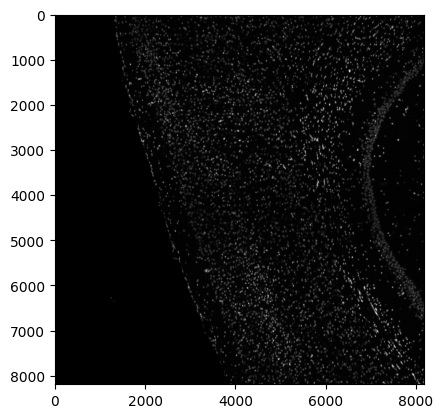

In [6]:
img = sliced_tiffs[4]

import cv2
# Gaussian blur
blur = cv2.GaussianBlur(img, (51, 51), sigmaX=0)

import matplotlib.pyplot as plt
plt.imshow(blur, cmap='gray')
plt.show()


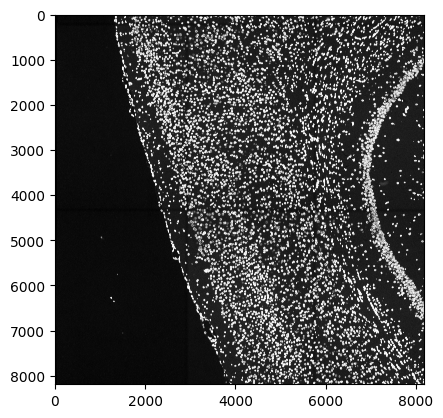

In [10]:
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)  # X-gradient
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)  # Y-gradient

# Magnitude of gradient
sobel_mag = np.sqrt(sobelx**2 + sobely**2)
sobel_mag = np.uint8(np.clip(sobel_mag, 0, 255))

plt.imshow(sobel_mag, cmap='gray')
plt.show()

In [ ]:
sobel_norm = sobel_mag / sobel_mag.max()
coord_norm = coord_array / 255.0


loss = np.mean((sobel_norm - coord_norm) ** 2)
print(loss) 

# 0.13790908164631518
# 0.1379087414103532
# 0.13790913980449954

0.13790913980449954


In [45]:
from scipy.ndimage import distance_transform_edt

# Distance from nearest coordinate point
distance_map = distance_transform_edt(1 - coord_array)
distance_map = np.exp(-distance_map / 5.0)  # Convert to soft mask

mask = cv2.dilate(coord_array, np.ones((15, 15)))  # Dilate the sparse coord map
masked_sobel = sobel_norm[mask > 0]
masked_target = distance_map[mask > 0]

loss = np.mean((masked_sobel - masked_target) ** 2)
print(loss)

# Normalize
sobel_norm = sobel_mag / sobel_mag.max()
distance_map = distance_map / distance_map.max()

loss = np.mean((sobel_norm - distance_map) ** 2)
print(loss)

# 0.1351555369779113

0.13356614199287434
0.1351555369779113


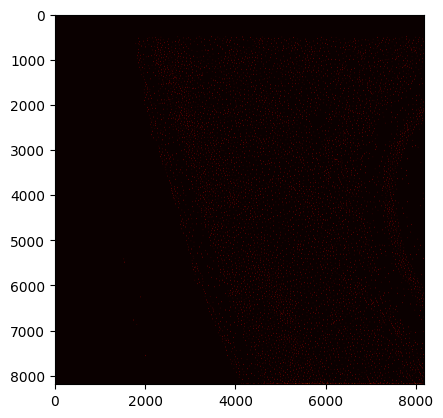

In [55]:
def generate_heatmap(coords, image_shape, sigma=5, patch_size=21):
    """
    coords: list of (x, y) points or a binary image with 1s at points of interest
    image_shape: (H, W)
    """
    heatmap = np.zeros(image_shape, dtype=np.float32)

    # Make 2D Gaussian patch
    k = patch_size // 2
    gaussian_1d = cv2.getGaussianKernel(patch_size, sigma)
    gaussian_2d = gaussian_1d @ gaussian_1d.T

    # Coordinates where coord_array == 1 (you can also directly pass list of coords)
    ys, xs = np.where(coords > 0)

    for x, y in zip(xs, ys):
        # Boundaries for placing the patch
        x1, x2 = max(x - k, 0), min(x + k + 1, image_shape[1])
        y1, y2 = max(y - k, 0), min(y + k + 1, image_shape[0])

        # Patch boundaries (trim if on edge)
        gx1, gx2 = k - (x - x1), k + (x2 - x)
        gy1, gy2 = k - (y - y1), k + (y2 - y)

        heatmap[x1:x2, y1:y2] += gaussian_2d[gx1:gx2, gy1:gy2]

    return np.clip(heatmap, 0, 1)

# Generate heatmap
heatmap = generate_heatmap(coord_array, coord_array.shape, sigma=5)

if heatmap.max() > 0:
    heatmap /= heatmap.max()  # Normalize to [0, 1]
else:
    print("Heatmap is all zeros!")

plt.imshow(heatmap, cmap='hot')
plt.show()


In [53]:
print("Number of active coordinates:", np.count_nonzero(coord_array))

Number of active coordinates: 6941


In [38]:
import torch
import torch.nn.functional as F

loss = F.binary_cross_entropy(torch.tensor(sobel_norm), torch.tensor(coord_norm))
print(loss)

tensor(9.8913, dtype=torch.float64)


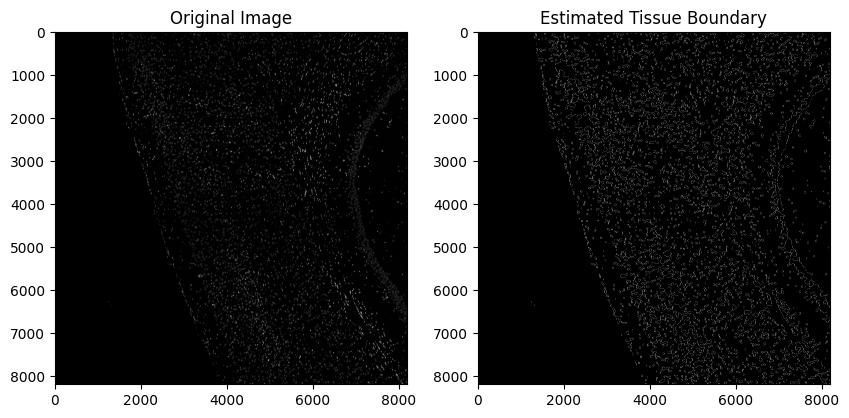

In [9]:
# Threshold using Otsu
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Morphological closing
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51,51))
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
closed_8bit = closed.astype(np.uint8)

# Find contours
contours, _ = cv2.findContours(closed_8bit, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours
boundary_mask = np.zeros_like(img)
cv2.drawContours(boundary_mask, contours, -1, 255, thickness=2)

# Show
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(boundary_mask, cmap='gray')
plt.title("Estimated Tissue Boundary")
plt.show()

In [ ]:
def sobel_edge_detection(img):
    # Convert image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply Sobel operator
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

In [ ]:
# plot some of the slices
import matplotlib.pyplot as plt
for i in range(2):
    plt.imshow(sliced_tiffs[i], cmap='gray')
    plt.show()

In [ ]:
img = sliced_tiffs[0]

plt.imshow(img, cmap='gray')
plt.show()

brightened_img = img + 200

plt.imshow(brightened_img, cmap='gray')
plt.show()

In [82]:
all_sliced_data = pd.concat(sliced_data)

print(f"Total after slicing: {len(all_sliced_data)}")
print(f"Unique cells after slicing: {all_sliced_data['cell_id'].nunique()}")

Total after slicing: 2096622
Unique cells after slicing: 349433
